# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Trabajo Practico 1

Autores: Lopez Cruz Juan Carlos y Nahuel Siles

# Introducción

Diseñar un filtro pasaaltos **Chebyshev** que cumpla con la siguiente plantilla:

<img src="./plantilla_tp1.png" /> 

## Items a tratar de la platilla:

1. Obtener el orden del filtro y hallar la función transferencia total. 

2. Obtener la transferencia de la red circuital a implementar. 

3. Simulación numérica/simbólica de la función transferencia en Python. 

4. Simulación circuital. Incluya el modelo real del OPAMP.

## Implementacion del armado:

1. Disenar el Layout del PCB.

2. Usar conectores, headers o borneras para alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y salida ( test points )  

3. Utilizar un zócalo DIP 14 para colocar el OPAMP y DIP 16 para el OTA.

4. Incluir resistores variables ( presets / trimmer ) o bien resistores fijos con tolerancias del 1%.

5. Agregar capacitores de bypass en la alimentacion del Amplificador. Agregar capacitor electrolítico o poliéster de 1 µF a 100 µF con otro cerámico de 100 nF a 470 nF en paralelo para reducir el ruido de la fuente.

## Medicion:

<img src="./forma_de_medicion_tp1.png" /> 

1. Verificar visualmente y con el multímetro que el circuito no tiene cortocircuitos y que los componentes estén correctamente soldados. 

2. Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se debe poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente.   

3. Setear la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito.  Tenga en cuenta que la medición mejora para niveles más altos de fuente.

4. Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de AC y periodo de esta señal de prueba con los medidores del DSO.

5. Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de  valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.

6. Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada. Verifique que el DSO tenga señal a la salida. Debe ser de la misma forma ( sin distorsión ) que la entrada con una cierta fase y alguna diferencia de amplitud probablemente.

7. Llegado a este punto está en condiciones de realizar un barrido con frecuencia.

## Resolucion:

### Normalizacion de la plantilla

Primeramente procedemos a normalizar nuestra plantilla, para ello tomamos como norma de frecuencia a $\Omega_\omega = \omega_p = 2\pi f_p$ por lo que queda de la siguiente manera:

* $\omega_{p_n} = \frac{\omega_p}{\omega_p} = 1$
* $\omega_{s_n} = \frac{\omega_s}{\omega_p} = \frac{f_s}{f_p} = \frac{100Hz}{300Hz} = \frac{1}{3} = 0.33$

### Transformacion de la plantilla

Ahora procedemor a transformar nuestra plantilla pasa alto a una pasa bajos, para ello calculamos nuestras $\omega_{p_{LP}}$ y $\omega_{s_{LP}}$.

* $\omega_{p_{LP}} = \frac{1}{\omega_{p_n}} = 1$
* $\omega_{s_{LP}} = \frac{1}{\omega_{s_n}} = \frac{1}{\frac{1}{3}} = 3$

### Obtencion de la Transferencia

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2 \, \omega_p^{2n}}} \right)
$$

Si $\omega = \omega_p = 1$:

$$
\alpha_{\text{max}} = -20 \log \left( \frac{1}{\sqrt{1 + \xi^2}} \right) = -20 \left( -\frac{1}{2} \log(1 + \xi^2) \right)
$$

$$
\alpha_{\text{max}} = 10 \log(1 + \xi^2)
$$

Como nuestra $\alpha_{\text{max}} = 1$ nos queda que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1 = 10^{0.1*1} - 1 = 0.2589$, por lo tanto nos queda que

$$
\xi = \sqrt{0.2589} = 0.5088
$$

Ahora calcularemos n.

$$
\alpha_{\min} = 10 \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
\frac{\alpha_{\min}}{10} = \log \left(1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} = 1 + \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
10^{\frac{\alpha_{\min}}{10}} - 1 = \xi^2 \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2} = \cosh^2\left(n \cosh^{-1}(w)\right)
$$

$$
\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}} = \cosh\left(n \cosh^{-1}(w)\right)
$$

$$
\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right) = n \cosh^{-1}(w)
$$

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{\frac{\alpha_{\min}}{10}} - 1}{\xi^2}}\right)}{\cosh^{-1}(w)}
$$

Como sabemos que $\xi^2 = 10^{0.1\alpha_{\text{max}}} - 1$ nos queda de la siguiente manera

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\alpha_{\min}} - 1}{10^{0.1\alpha_{\text{max}}} - 1}}\right)}{\cosh^{-1}(w)}
$$

Ya con la formula despejada solo nos queda reemplazar los valores.

$$
n = \frac{\cosh^{-1}\left(\sqrt{\frac{10^{0.1\cdot30dB} - 1}{10^{0.1\cdot1dB} - 1}}\right)}{\cosh^{-1}(3)}
$$

$$
n = 2.73
$$

Como n = 2.73 tiene que ser un numero natural, redondeamos para arriba para asi cumplir con la condicion de la plantilla, por lo que nos queda que n = 3.

### Obtencion de la transferencia normalizada

Para este desarrollo tendremos en cuenta la siguiente identidad:

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

Ya con esto definido empezamos nuestro desarrollo.

$$
|H(j\omega)|^2 = H(j\omega)\cdot H(-j\omega) = H(s)H(-s)
$$

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 C_n^2(\omega)}
$$

Para trabajar con el polinomio de Chebishev sabemos que $C_n^2(\omega) = 2\omega C_{n-1}(\omega) - C_{n-2}(\omega)$ donde $C_0(\omega) = 1$ y $C_1(\omega) = \omega$, con esto procedemos a calcular el polinomio de Chebyshev

$$
C_2(\omega) = 2\omega^2 - 1
$$

$$
C_3(\omega) = 2\omega(2\omega^2 -1) - \omega = 4\omega^3 - 3\omega
$$

Ahora sustituimos lo obtenido

$$
|H(j\omega)|^2 = \frac{1}{1 + \xi^2 (4\omega^3 - 3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 ((4\omega^3)^2 -2\cdot4\omega^3\cdot3\omega + (3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 (16\omega^6 -24\omega^4 + 9\omega^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 16\omega^6 -\xi^2 24\omega^4 + \xi^2 9\omega^2}
$$

Como $\omega = \frac{s}{j}$ nos queda que:

$$
|H(s)|^2 =\frac{1}{1 + \xi^2 16(\frac{s}{j})^6 -\xi^2 24\frac{s}{j}^4 + \xi^2 9\frac{s}{j}^2}
$$

$$
|H(s)|^2 =\frac{1}{1 - \xi^2 16s^6 -\xi^2 24s^4 - \xi^2 9s^2}
$$

Usaremos la identidad mosttrada anteriormente para obtener nuestra transferencia.

$$
\left| T(j\omega) \right|^2 = T(j\omega) \cdot T(-j\omega) = T(s) \cdot T(-s)\big|_{s = j\omega}
$$

$$
\Rightarrow |H(s)|^2 =\frac{1}{1 - \xi^2 16s^6 -\xi^2 24s^4 - \xi^2 9s^2} = \frac{1}{s^3 \cdot a + s^2 \cdot b + s \cdot c + d}\frac{1}{-s^3 \cdot a + s^2 \cdot b - s \cdot c + d}
$$

Procedemos a igualar los coeficientes del denominador.

$$
-a^2 = -16\xi^2 \Rightarrow a = 4\xi = 2.0352
$$

$$
-24\xi^2 = b^2 - 2ac \quad (1)
$$

$$
-9\xi^2 = 2bd - c^2 \Rightarrow c = \sqrt{2bd + 9\xi^2} \quad (2)
$$

$$
d^2 = 1 \Rightarrow d = 1
$$

$(2) \Rightarrow (1)$

$$
-24\xi^2 = b^2 - 2a \cdot \sqrt{2b + 9\xi^2}
$$

$$
b^2 + 24\xi^2 = 2a \cdot \sqrt{2b + 9\xi^2}
$$

$$
(b^2)^2 + 2 \cdot 24\xi^2 \cdot b^2 + (24\xi^2)^2 = 64\xi^2 (2b + 9\xi^2)
$$

$$
b^4 + 48\xi^2 \cdot b^2 + 576\xi^4 = 128\xi^2 \cdot b + 576\xi^4
$$

$$
b^4 + 48\xi^2 \cdot b^2 - 128\xi^2 \cdot b = 0
$$

$$
b^3 + 48\xi^2 b - 128\xi^2 = 0
\Rightarrow b = 2.0116
$$

$$
\Rightarrow c = \sqrt{2bd + 9\xi^2} = c = \sqrt{2 \cdot 2.0116 + 9\xi^2}
$$

$$
c = 2.5205
$$

Con los coeficientes calculados podemos obtener nuestra transferencia.

$$
H(s) = \frac{1}{s^3 \cdot a + s^2 \cdot b + s \cdot c + d} = \frac{1}{s^3 \cdot 2.0352 + s^2 \cdot 2.0116 + s \cdot 2.5205 + 1}
$$

$$
H(s) = \frac{0.4913}{s^3 + s^2 \cdot 0.9884 + s \cdot 1.2384 + 0.4913}
$$

Ahora usaremo python para corroborar nuestro analisis

In [17]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys

In [9]:
#Epsilon
eps=np.sqrt(10**(1/10)-1)

#Raices
raices = np.roots([1,0,3/2,0,9/16,0,-1/((eps**2)*16)])
roots = raices[np.real(raices) < 0]

#Coeficientes
coeff = np.poly(roots)
coeff = np.round(coeff,4)

k = np.sqrt(1/((eps**2)*(16)))
k = np.round(k,4)

#Variable "S"
s = sp.symbols('s')

#Transferencia de quinto orden
den = sp.Poly(coeff,s)
Ts  = sp.simplify(k) / sp.simplify(den)

display(Math(r'T(s) = ' + sp.latex(Ts)))

<IPython.core.display.Math object>

Podemos notar que es igual a la transferecia calculada anteriormente

### Construccion de la Transferencia en secciones

Podemos observar que para construir nuestra transferecia usaremos una seccion de segundo orden y una de primer orden, por lo que procedemos a calcular los polos de nuestra transferecia.

In [72]:
#Redondeo a 4 decimales
roots = np.round(roots,4)

#Muestro los polos
for i, r in enumerate(roots):
    print(f"Polo {i+1} = {r.real} + {r.imag}")

Polo 1 = -0.2471 + 0.966
Polo 2 = -0.2471 + -0.966
Polo 3 = -0.4942 + 0.0


Con los polos podemos obetener los coeficientes de cada seccion de nuestra transferencia

In [74]:
#Coeficientes de las secciones
pol1 = np.array([roots[0], roots[1]])
pol2 = roots[2]

print(np.round(np.poly(pol1),4))
print(np.abs(pol2))

[1.     0.4942 0.9942]
0.4942


Una vez calculado nuestro coeficientes de nuetra transfereciaprocedemos a armar la misma.

$$
T(s)= \frac{0.4942}{s + 0.4942} \frac{K_1 \cdot 0.9942}{s^2 + s \cdot 0.4942 + 0.9942}
$$

Ahora procedemos a calcular la ganancia de la seccion de segundo orden.

$$
0.4942\cdot(K_1\cdot0.9942) = 0.4913
$$

$$
K_1 = 1
$$

Ahora reemplazamos las ganancias calculadas en nuestra transferencia.

$$
T(s)= \frac{0.4942}{s + 0.4942} \frac{1 \cdot 0.9942}{s^2 + s \cdot 0.4942 + 0.9942}
$$

### Verificacion de la plantilla pasa bajo

Procedemos a verificar la transferencia obtenida

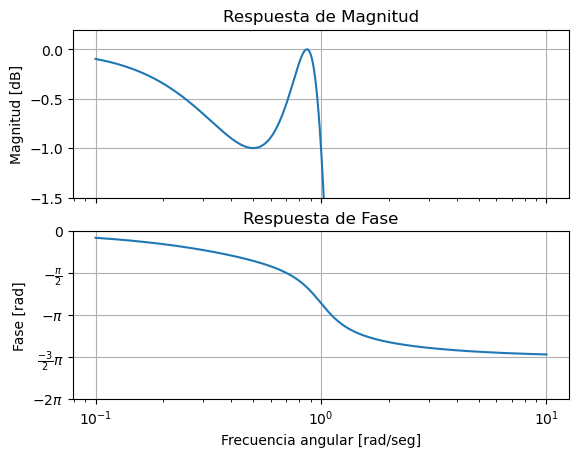

In [82]:
#Secciones
H1=sig.TransferFunction(0.9942,np.poly(pol1))
H2=sig.TransferFunction(0.4942,[1,np.abs(pol2)])

#Numerador y denominador total
num = np.polymul(H1.num, H2.num)
den = np.polymul(H1.den, H2.den)

#Función trasnferencia
TS=sig.TransferFunction(num,den)

#Diagrama de bode
_, axes = bodePlot(TS)
axes[0].set_ylim(-1.5,0.2)
plt.show()

Podemos observar que nuestra transferencia oscila entre 0 y -1dB a lo largo de la banda de paso, cumpliendo con el $\alpha_{max}$ propuesto.

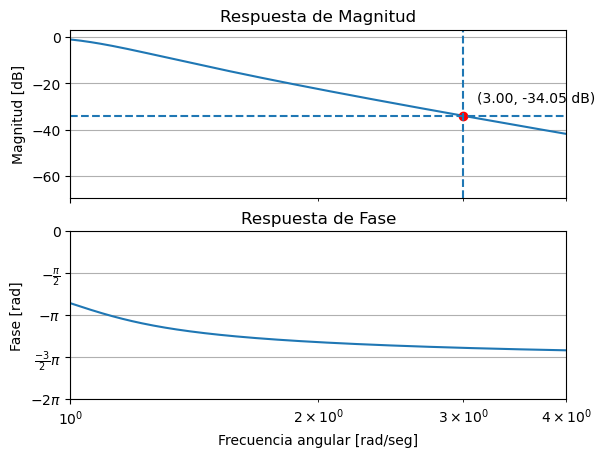

In [99]:
_, axes = bodePlot(TS)

axes[0].set_xlim(1,4)

# Frecuencia a marcar
w_point = 3

# Obtener datos de la curva ya dibujada
line = axes[0].lines[0]   # primera curva (magnitud)
omega = line.get_xdata()
mag_db = line.get_ydata()

# Interpolar valor en w = 3
mag_point = np.interp(w_point, omega, mag_db)

# Dibujar el punto
axes[0].plot(w_point, mag_point, 'ro')

# (opcional) guías
axes[0].axvline(w_point, linestyle='--')
axes[0].axhline(mag_point, linestyle='--')

axes[0].annotate(
    f"({w_point:.2f}, {mag_point:.2f} dB)",
    (w_point, mag_point),
    textcoords="offset points",
    xytext=(10,10),
    ha='left'
)

plt.show()

Vemos también que para $\omega = 3$ hubo una caida mayor a 30dB por lo que se cumple la atenuacion minima de nuestra plantilla.

### Transformacion de la transferencia

Con nuestra verificada procedemos a transformar nuestra transferecia pasa bajos a una pasa altos usando el siguiente nucleo de transformacion.

$$
p = K(s) = \frac{1}{s}
$$

Usando el nucleo nos queda la transferencia de la siguiente forma.

$$
T_{HP}(s)= \frac{0.4942}{\frac{1}{s} + 0.4942} \frac{1 \cdot 0.9942}{(\frac{1}{s})^2 + \frac{1}{s} \cdot 0.4942 + 0.9942}
$$

$$
T_{HP}(s)= \frac{s \cdot 0.4942}{1 + s \cdot 0.4942} \frac{s^2 \cdot 0.9942}{1 + s \cdot 0.4942 + s^2 \cdot 0.9942}
$$

$$
T_{HP}(s)= \frac{s}{s + 2.0234} \frac{s^2}{s^2 + s \cdot 0.497 + 1.0058}
$$

### Verificacion de la plantilla pasa altos

Procedemos e verificar nuestra transferencia pasa altos

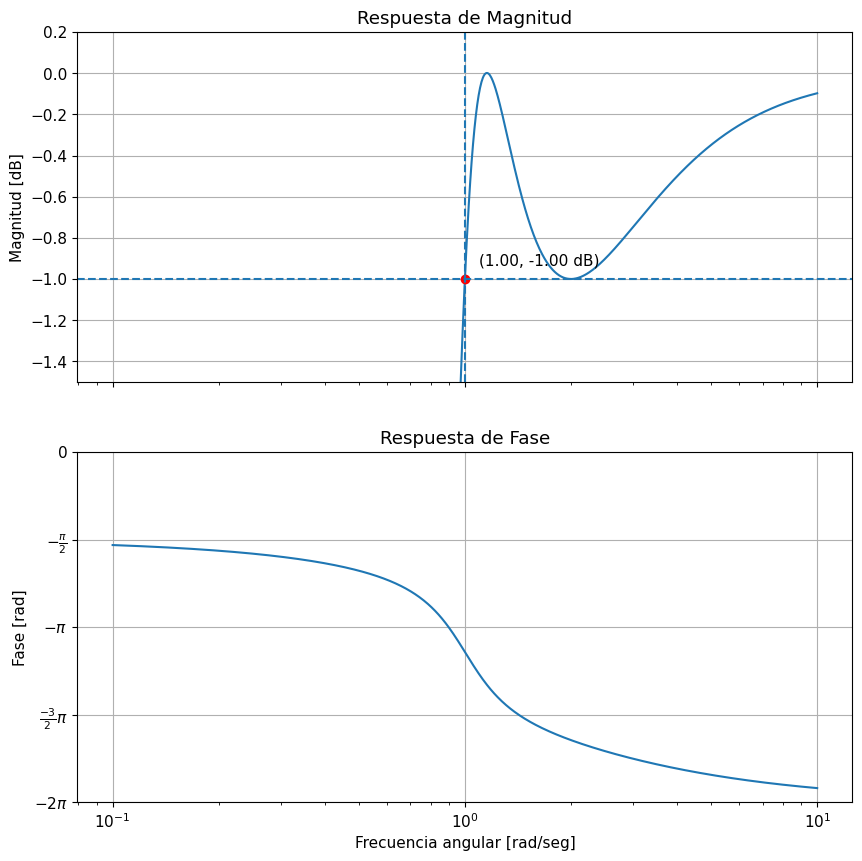

In [36]:
# Cargamos la funcion transferencia como vectores de sus coeficientes.

num_1 = np.array([ 1, 0])
den_1 = np.array([ 1, 2.0234])

num_2 = np.array([ 1, 0, 0])
den_2 = np.array([ 1, 0.497, 1.0058])

num = np.polymul(num_1, num_2)
den = np.polymul(den_1, den_2)

H1 = sig.TransferFunction( num, den )

# Graficamos el diagrama de polos y ceros
# Graficamos la respuesta en frecuencia para el modulo y la fase.

_, axes = bodePlot(H1)

# Frecuencia a marcar
w_point = 1

# Obtener datos de la curva ya dibujada
line = axes[0].lines[0]   # primera curva (magnitud)
omega = line.get_xdata()
mag_db = line.get_ydata()

# Interpolar valor en w = 1/3
mag_point = np.interp(w_point, omega, mag_db)

# Dibujar el punto
axes[0].plot(w_point, mag_point, 'ro')

# (opcional) guías
axes[0].axvline(w_point, linestyle='--')
axes[0].axhline(mag_point, linestyle='--')

axes[0].annotate(
    f"({w_point:.2f}, {mag_point:.2f} dB)",
    (w_point, mag_point),
    textcoords="offset points",
    xytext=(10,10),
    ha='left'
)

#Diagrama de bode
axes[0].set_ylim(-1.5,0.2)
plt.show()


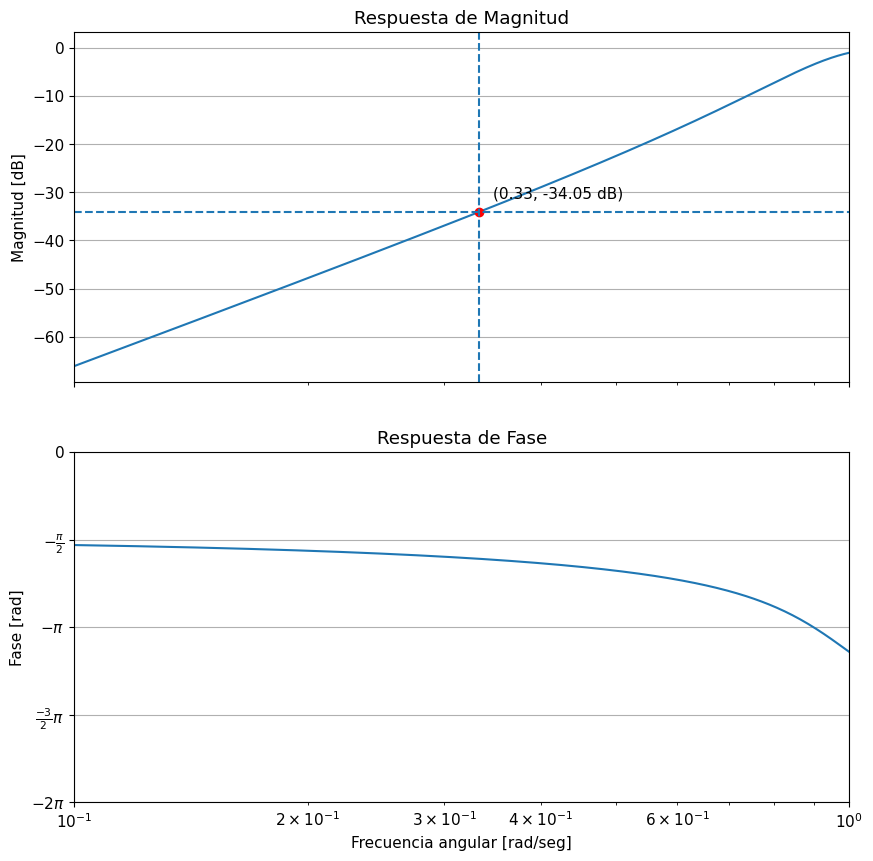

In [30]:
_, axes = bodePlot(H1)

axes[0].set_xlim(0.1,1)

# Frecuencia a marcar
w_point = 1/3

# Obtener datos de la curva ya dibujada
line = axes[0].lines[0]   # primera curva (magnitud)
omega = line.get_xdata()
mag_db = line.get_ydata()

# Interpolar valor en w = 1/3
mag_point = np.interp(w_point, omega, mag_db)

# Dibujar el punto
axes[0].plot(w_point, mag_point, 'ro')

# (opcional) guías
axes[0].axvline(w_point, linestyle='--')
axes[0].axhline(mag_point, linestyle='--')

axes[0].annotate(
    f"({w_point:.2f}, {mag_point:.2f} dB)",
    (w_point, mag_point),
    textcoords="offset points",
    xytext=(10,10),
    ha='left'
)

plt.show()

Podemos observar, que igual a la transferencia pasa bajos, se cumple los $\alpha_{max}$ y $\alpha_{min}$

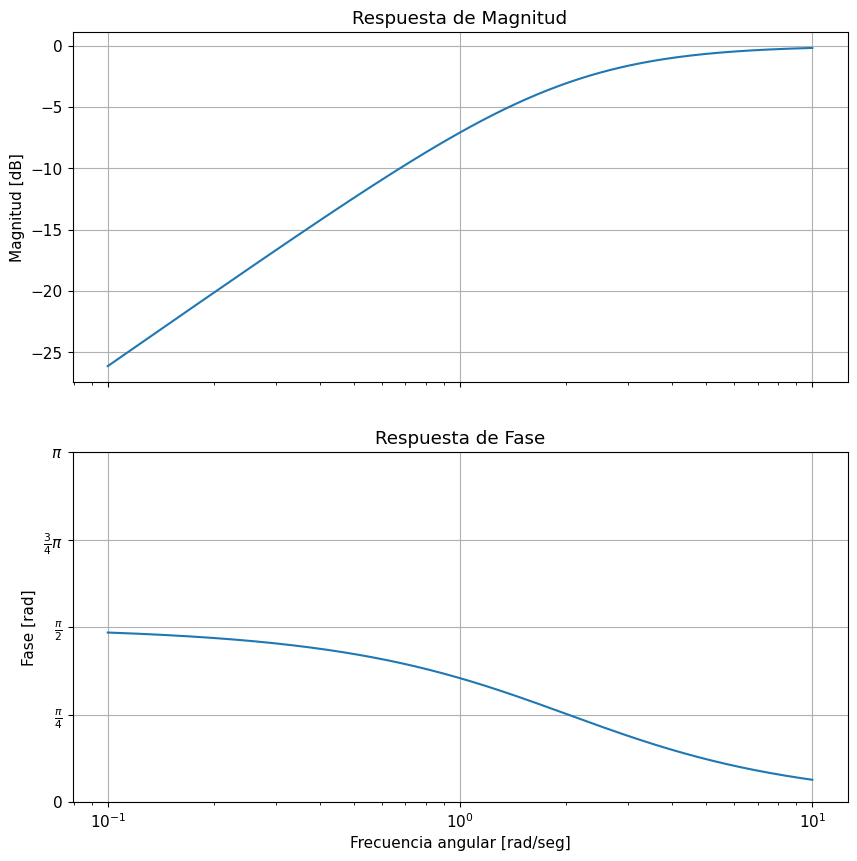

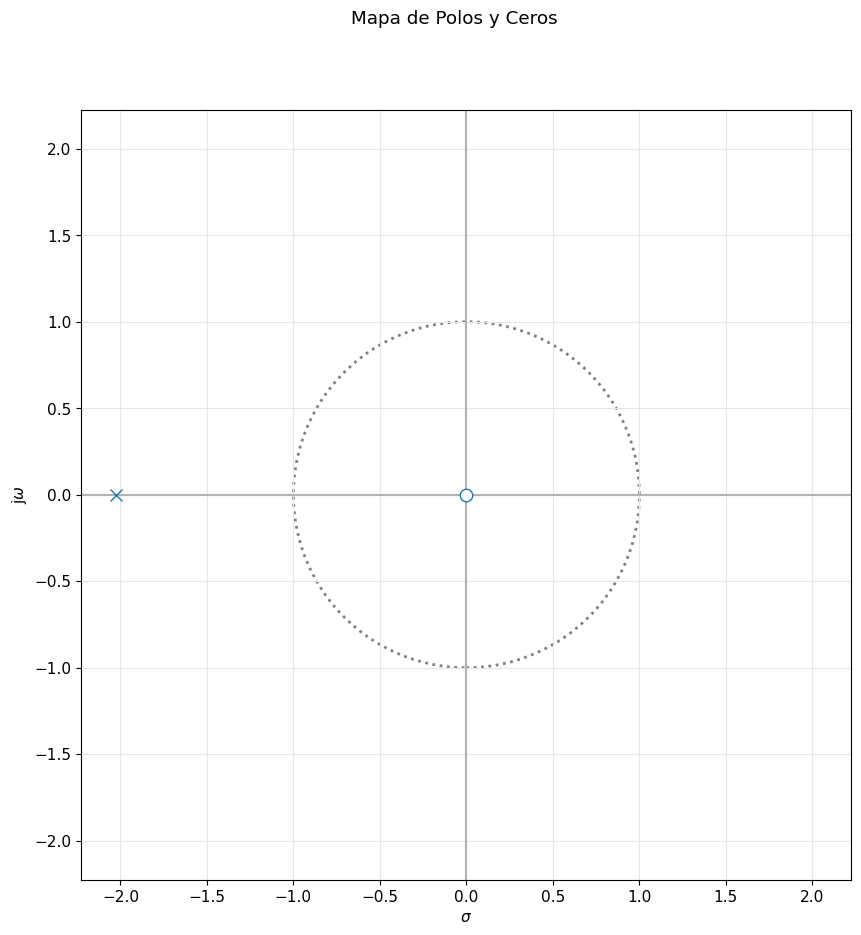

In [49]:
# Cargamos la funcion transferencia como vectores de sus coeficientes.
num_1 = np.array([ 1, 0])
den_1 = np.array([ 1, 2.0234])

H = sig.TransferFunction( num_1, den_1 )

# Graficamos el diagrama de polos y ceros
# Graficamos la respuesta en frecuencia para el modulo y la fase.

_, axes_hdl = bodePlot(H)

# para que se vea como uno intuye el módulo. Probar comentar las siguientes 2 líneas
plt.sca(axes_hdl[0])
#plt.ylim([-1,1])

plt.gca

pzmap(H)

plt.show()


In [ ]:
f = 